# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Load dataset
dataset = pd.read_csv('car_purchase_data.csv')

# Preview the first few rows
print("Dataset shape:", dataset.shape)
display(dataset.head())

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-mnkqc_ak because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


Dataset shape: (400, 5)


,User ID,Gender,Age,Salary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


### Step 2: Split features and target

In [2]:
# Use Age and Salary as features, and Purchased as the target
X = dataset[['Age', 'Salary']]
y = dataset['Purchased']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
display(X.head())
display(y.head())

Feature matrix shape: (400, 2)
Target vector shape: (400,)


,Age,Salary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000


0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64

### Step 3: Train/Test Split

In [3]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (320, 2)
X_test shape: (80, 2)
y_train shape: (320,)
y_test shape: (80,)


### Step 4: Feature Scaling

In [4]:
# Scale the features so logistic regression performs better
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("First 5 scaled training rows:")
print(X_train[:5])

First 5 scaled training rows:
[[ 1.92295008  2.14601566]
 [ 2.02016082  0.3787193 ]
 [-1.3822153  -0.4324987 ]
 [-1.18779381 -1.01194013]
 [ 1.92295008 -0.92502392]]


### Step 5: Train Logistic Regression Model

In [5]:
# Train the Logistic Regression model
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)

print("Model intercept:", classifier.intercept_)
print("Model coefficients:", classifier.coef_)

Model intercept: [-0.87067834]
Model coefficients: [[2.00319272 1.08067231]]


### Step 6: Predict and Evaluate

In [6]:
# Predict test set results
y_pred = classifier.predict(X_test)

# Evaluation metrics
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
print("\nAccuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[57  1]
 [ 5 17]]

Accuracy: 92.5 %

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95        58
           1       0.94      0.77      0.85        22

    accuracy                           0.93        80
   macro avg       0.93      0.88      0.90        80
weighted avg       0.93      0.93      0.92        80



### Step 7: Visualization of Decision Regions

/tmp/ipykernel_2389/3634170069.py:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


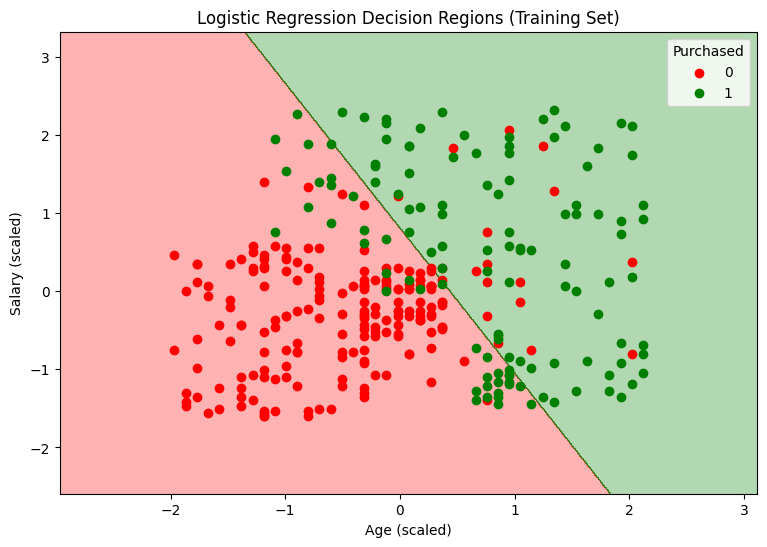

In [7]:
# Visualize the decision boundary using the training set
from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train.to_numpy()

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

plt.figure(figsize=(9, 6))
plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.3,
    cmap=ListedColormap(('red', 'green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0], X_set[y_set == j, 1],
        c=ListedColormap(('red', 'green'))(i),
        label=j
    )

plt.title('Logistic Regression Decision Regions (Training Set)')
plt.xlabel('Age (scaled)')
plt.ylabel('Salary (scaled)')
plt.legend(title='Purchased')
plt.show()

## IV. Reflection Questions 
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


## Reflection Answers

**1. Logistic regression outputs probabilities — why can it still be used for classification?**  
Logistic regression predicts the probability that a sample belongs to the positive class, usually a value between 0 and 1. It can still be used for classification because we apply a threshold, commonly 0.5. If the predicted probability is 0.5 or higher, the model predicts class 1 (purchased). If it is below 0.5, the model predicts class 0 (not purchased). This makes logistic regression a probability-based classifier.

**2. Based on your model, which customers are more likely to purchase a car?**  
Based on the decision boundary and the training pattern, customers with higher salaries and middle-to-older ages are more likely to purchase a car. In this dataset, purchase behavior tends to increase as age rises and salary becomes higher. Younger customers with lower salaries are less likely to purchase.

**3. What factors might cause low accuracy in this task?**  
Low accuracy could happen for several reasons. The features might not fully explain customer purchase behavior, the training and testing split might produce difficult cases, there may be overlap between the two classes, or the data may contain noise. Another issue could be insufficient preprocessing or using too few features to capture the full pattern.

**4. Propose additional features or preprocessing steps that could improve performance.**  
Performance could improve by adding more useful features such as occupation, education level, marital status, location, previous purchase history, or credit score. Preprocessing improvements could include removing irrelevant columns, encoding categorical variables such as gender, testing feature selection methods, handling outliers, and tuning model hyperparameters. Trying cross-validation could also help produce a more reliable model.